---

# Quiz Matdis II Lanjut ke 1 Praktikum ~ Dosen TG

**Soal Kode 3**

---

## Petunjuk Umum

Untuk menjawab setiap soal, Anda harus menyertakan kode Python sebagai bukti pengerjaan.

Untuk setiap soal, ikuti langkah-langkah berikut:

1. **Representasi & Analisis Awal:**
   Ubah narasi menjadi representasi graf formal (misalnya *Adjacency Matrix*) dan lakukan analisis awal (misalnya, analisis derajat) untuk mendapatkan intuisi solusi.

2. **Implementasi & Solusi:**
   Gunakan *networkx* untuk memodelkan graf, terapkan algoritma yang relevan untuk menemukan solusi, dan visualisasikan hasilnya dengan *matplotlib*.

3. **Analisis HOTS:**
   Jawab pertanyaan analisis tingkat lanjut yang mungkin memiliki beberapa jawaban valid, dan berikan justifikasi yang kuat untuk mendukung argumen Anda.




---

## 1. Perancangan Jaringan Fiber Optik Lintas Zona

Sebuah kota berencana membangun jaringan fiber optik untuk menghubungkan Data Center (DC) dengan Universitas (U). Peta infrastruktur melalui beberapa titik infrastruktur (A, B, C, D). Kota ini terbagi menjadi 3 zona regulasi: **Zona 1, Zona 2, dan Zona 3**.
Biaya pemasangan kabel dihitung per kilometer, tetapi ada biaya izin sebesar **50 unit** setiap kali kabel melintasi batas antar zona.

### Data Jaringan dan Zona:

| Titik | Zona | Koneksi Ke | Jarak (KM) |
| ----- | ---- | ---------- | ---------- |
| DC    | 1    | A          | 10         |
| A     | 1    | B          | 15          |
| B     | 1    | C          | 8          |
| U     | 3    | D          | 7          |
| C     | 2    | A          | 12         |
| C     | 2    | D          | 20         |
| D     | 2    | B          | 18         |

---

### Representasi & Analisis Awal:

* Buatlah *Adjacency Matrix* untuk jaringan ini berdasarkan **Jarak (km)**.
* Secara manual, telusuri jalur dari **DC ke U**. Identifikasi setiap kali sebuah jalur potensial melintasi batas zona. Misalnya, dari node di Zona 1 ke node di Zona 2. Berdasarkan observasi ini, jalur mana yang secara intuitif Anda duga akan menjadi jalur "termurah" setelah memperhitungkan biaya izin?

---

### Implementasi & Solusi:

* Gunakan *networkx* untuk membuat `nx.Graph()`. Tambahkan atribut **zone** pada setiap node dan **distance** pada setiap sisi.
* Buat sebuah atribut sisi baru bernama **effective_cost**.
  Lakukan iterasi pada semua sisi:

  * Jika sebuah sisi menghubungkan dua node dengan zona berbeda, `effective_cost = distance + 50`.
  * Jika tidak, `effective_cost = distance`.
* Terapkan **Algoritma Dijkstra** untuk mencari jalur terpendek dari **DC ke U** dengan menggunakan `weight="effective_cost"`.
* Visualisasikan graf.

  * Warnai node berdasarkan zonanya (Zona 1: biru, Zona 2: hijau, Zona 3: kuning).
  * Sorot **jalur termurah** yang Anda temukan dan tampilkan label `effective_cost` pada sisinya.

---

### Analisa

Pemerintah kota mengusulkan pembangunan **"Hub Antar-Zona"** baru di titik **C**.

* Pembangunan ini akan membuat biaya izin menjadi **0** untuk koneksi apa pun yang melewati **C** di masa depan.
* Namun, biaya pembangunan hub itu sendiri sangat mahal.

Berdasarkan jalur termurah yang Anda temukan untuk proyek tunggal ini (DC ke U):

* Apakah investasi pembangunan Hub tersebut dapat dibenarkan?
* Kapan investasi ini menjadi lebih masuk akal?

Diskusikan *trade-off* antara **biaya modal awal yang tinggi** (membangun hub) versus **penghematan biaya operasional jangka panjang** (menghilangkan biaya izin).

---





Jalur terpendek dari DC ke U: ['DC', 'A', 'C', 'D', 'U']
Total biaya efektif (termurah): 149


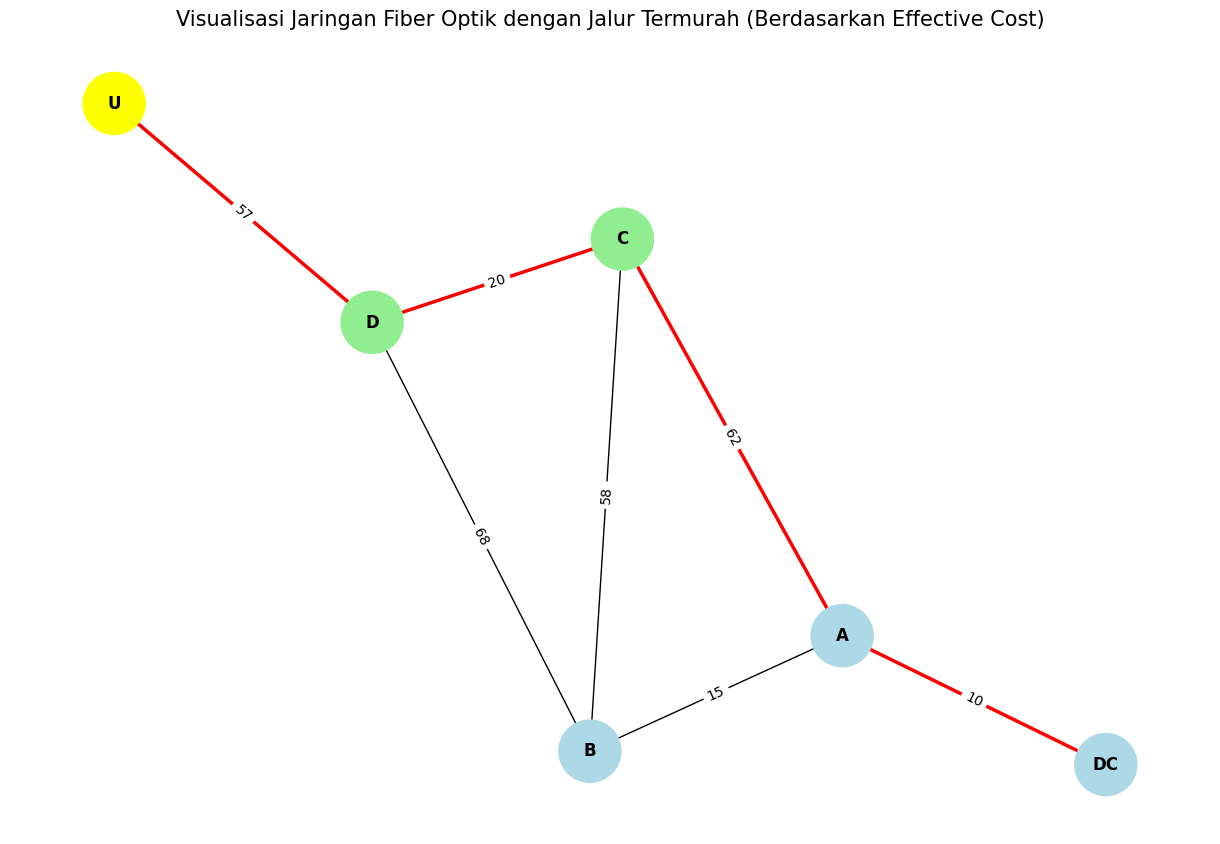

In [1]:
#isi sesuai instruksi nomor 1


import networkx as nx
import matplotlib.pyplot as plt

# --- Implementasi & Solusi ---

# 1. Membuat Graf
G = nx.Graph()

# 2. Menambahkan Atribut Node (Titik dan Zona)
nodes_data = {
    "DC": {"zone": 1},
    "A": {"zone": 1},
    "B": {"zone": 1},
    "C": {"zone": 2},
    "D": {"zone": 2},
    "U": {"zone": 3}
}
for node, attrs in nodes_data.items():
    G.add_node(node, **attrs)

# 3. Menambahkan Sisi dengan Atribut Jarak (distance)
edges_data = [
    ("DC", "A", 10),
    ("A", "B", 15),
    ("B", "C", 8),
    ("U", "D", 7),
    ("C", "A", 12),
    ("C", "D", 20),
    ("D", "B", 18)
]
G.add_weighted_edges_from(edges_data, weight='distance')

# 4. Menghitung dan Menambahkan Atribut Sisi Baru 'effective_cost'
for u, v, data in G.edges(data=True):
    zone_u = G.nodes[u]['zone']
    zone_v = G.nodes[v]['zone']
    distance = data['distance']

    if zone_u != zone_v:
        effective_cost = distance + 50
    else:
        effective_cost = distance

    G[u][v]['effective_cost'] = effective_cost

# 5. Menerapkan Algoritma Dijkstra
source_node = "DC"
target_node = "U"
shortest_path = nx.dijkstra_path(G, source=source_node, target=target_node, weight='effective_cost')
shortest_path_length = nx.dijkstra_path_length(G, source=source_node, target=target_node, weight='effective_cost')

print(f"Jalur terpendek dari {source_node} ke {target_node}: {shortest_path}")
print(f"Total biaya efektif (termurah): {shortest_path_length}")

# --- Visualisasi Graf ---

# Posisi node untuk visualisasi
pos = nx.spring_layout(G, seed=42)

# Warna node berdasarkan zona
zone_colors = {1: 'lightblue', 2: 'lightgreen', 3: 'yellow'}
node_colors = [zone_colors[G.nodes[node]['zone']] for node in G.nodes()]

# Menggambar graf dasar
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=2000, font_size=12, font_weight='bold')

# Menyorot jalur termurah
path_edges = list(zip(shortest_path, shortest_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2.5)

# Menambahkan label 'effective_cost' pada sisi
edge_labels = nx.get_edge_attributes(G, 'effective_cost')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black')

plt.title("Visualisasi Jaringan Fiber Optik dengan Jalur Termurah (Berdasarkan Effective Cost)", size=15)
plt.show()


## 2. Rute Penyapu Jalan di Distrik Bersejarah

Sebuah kendaraan penyapu jalan otomatis harus membersihkan setiap jalan di sebuah distrik bersejarah dan kembali ke **Depot (D)**. Distrik ini memiliki dua jenis jalan:

* **Jalan Protokol** (lebar, dua arah).
* **Gang Sempit** (satu arah dan hanya boleh dilewati sesuai arahnya).

### Data Jaringan Jalan:

* **Node (Persimpangan):** D (Depot), A, B, C, E
* **Jalan Protokol (Dua Arah):** (D-A), (A-B), (B-C)
* **Gang Sempit (Satu Arah):** (A → B), (A → C), (C → E), (E → D)

---

### Representasi & Analisis Awal:

* Modelkan jaringan ini. *Adjacency List* adalah pilihan yang baik di sini, di mana Anda bisa menandai apakah sebuah koneksi bersifat satu arah atau dua arah.
* Untuk setiap simpang (node), hitung tiga nilai: derajat masuk (dari gang satu arah), derajat keluar (dari gang satu arah), dan derajat dari jalan dua arah. berdasarkan angka angka ini analisislah apakah sebuah rute yang efisien (melewati setiap jalan tepat satu kali) memungkinkan.
* Petunjuk: Ini adalah masalah **Sirkuit Euler pada Graf Campuran/Mixed Graph**.

---

### Implementasi & Solusi:

* Gunakan *networkx* untuk membuat `nx.MultiDiGraph()`.
* Modelkan jalan dua arah sebagai dua sisi berlawanan (`G.add_edge('D', 'A')` dan `G.add_edge('A', 'D')`).
* Modelkan gang satu arah sebagai satu sisi saja (`G.add_edge('D', 'B')`).
* Tulis sebuah fungsi atau logika sederhana untuk memeriksa kondisi **Sirkuit Euler** pada graf campuran:

  * Untuk setiap node, selisih antara `in_degree` dan `out_degree` harus **0**.
* Visualisasikan *MultiDiGraph* tersebut. Gunakan gaya panah yang jelas untuk membedakan gang satu arah.
* Berikan label pada setiap node.

---

### Analisis

Analisis Anda menunjukkan bahwa **Sirkuit Euler yang sempurna tidak mungkin dibuat**.
Dinas perhubungan ingin membuat perubahan minimal pada lalu lintas. Mereka memberikan dua proposal:

* **Proposal A:**
  Mengubah **satu gang satu arah** menjadi **jalan dua arah**.

* **Proposal B:**
  Menjadikan **satu jalan protokol** menjadi satu arah.

Analisislah kedua proposal tersebut.

* Proposal mana yang secara matematis paling efektif untuk “menyeimbangkan” derajat masuk/keluar di seluruh jaringan agar Sirkuit Euler dapat terbentuk?
* Tunjukkan jalan atau gang mana yang Anda pilih untuk diubah dan berikan justifikasi mengapa perubahan tersebut adalah yang paling efisien.

---

--- Memeriksa Kondisi Sirkuit Euler ---
Node D: In-Degree = 2, Out-Degree = 1
  -> Tidak seimbang (in ≠ out)
Node A: In-Degree = 2, Out-Degree = 4
  -> Tidak seimbang (in ≠ out)
Node B: In-Degree = 3, Out-Degree = 2
  -> Tidak seimbang (in ≠ out)
Node C: In-Degree = 2, Out-Degree = 2
Node E: In-Degree = 1, Out-Degree = 1

Kesimpulan: Tidak semua node seimbang. Sirkuit Euler sempurna tidak mungkin dibuat.


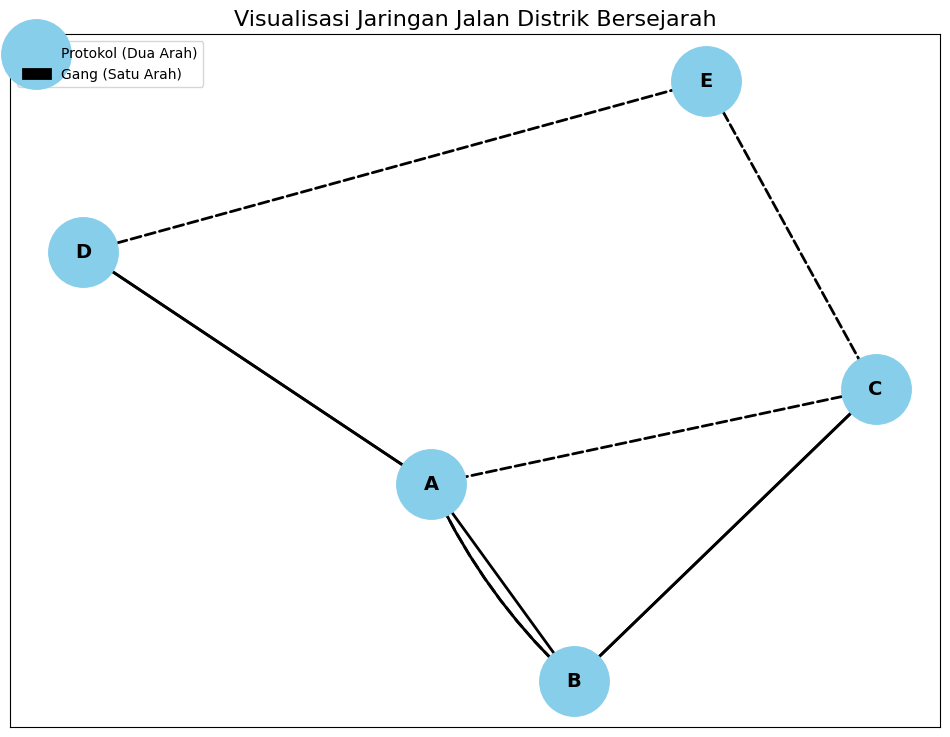

In [2]:
#isi sesuai instruksi nomor 2


import networkx as nx
import matplotlib.pyplot as plt

# --- Implementasi & Solusi ---

# 1. Membuat Graf Campuran (MultiDiGraph)
G = nx.MultiDiGraph()

# Node (Persimpangan)
nodes = ['D', 'A', 'B', 'C', 'E']
G.add_nodes_from(nodes)

# 2. Menambahkan Sisi (Jalan)
# Jalan Protokol (dua arah) dimodelkan sebagai dua sisi berlawanan
protokol_edges = [('D', 'A'), ('A', 'D'), ('A', 'B'), ('B', 'A'), ('B', 'C'), ('C', 'B')]
# Gang Sempit (satu arah)
gang_edges = [('A', 'B'), ('A', 'C'), ('C', 'E'), ('E', 'D')]

G.add_edges_from(protokol_edges, type='protokol')
G.add_edges_from(gang_edges, type='gang')

# 3. Fungsi untuk Memeriksa Kondisi Sirkuit Euler
def check_eulerian_condition(graph):
    print("--- Memeriksa Kondisi Sirkuit Euler ---")
    is_eulerian = True
    for node in graph.nodes():
        in_deg = graph.in_degree(node)
        out_deg = graph.out_degree(node)
        print(f"Node {node}: In-Degree = {in_deg}, Out-Degree = {out_deg}")
        if in_deg != out_deg:
            is_eulerian = False
            print(f"  -> Tidak seimbang (in ≠ out)")

    if is_eulerian:
        print("\nKesimpulan: Semua node memiliki in-degree = out-degree. Sirkuit Euler mungkin ada.")
    else:
        print("\nKesimpulan: Tidak semua node seimbang. Sirkuit Euler sempurna tidak mungkin dibuat.")
    return is_eulerian

# Memanggil fungsi pengecekan
check_eulerian_condition(G)

# --- Visualisasi Graf ---

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, seed=42, k=0.9)

# Menggambar node dan label
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

# Menggambar sisi dengan gaya berbeda
edge_styles = {
    'protokol': 'solid',
    'gang': 'dashed'
}

for u, v, data in G.edges(data=True):
    style = edge_styles.get(data.get('type'), 'solid')
    # Mengatur rad untuk sisi paralel agar tidak tumpang tindih
    rad = 0.1 if G.number_of_edges(u, v) > 1 else 0
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        style=style,
        width=2.0,
        arrowsize=20,
        connectionstyle=f'arc3,rad={rad}'
    )

plt.title("Visualisasi Jaringan Jalan Distrik Bersejarah", size=16)
plt.legend(['Protokol (Dua Arah)', 'Gang (Satu Arah)'], loc='upper left')
plt.show()
